# weather data :july to jan 8th

## Importing libraries

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## getting the data

In [2]:
import random
# Set the date range for half a year
date_range = pd.date_range(start="2024-07-08", end="2025-01-08", freq="D")
# Generate synthetic weather data
np.random.seed(42)  # For reproducibility
random.seed(42)
# Create temperature ranges
max_temp = np.round(np.random.uniform(25, 35, len(date_range)), 1)
min_temp = np.round(max_temp - np.random.uniform(5, 10, len(date_range)), 1)
avg_temp = np.round((max_temp + min_temp) / 2, 1)
temp_range = max_temp - min_temp
# Precipitation values
total_precip = np.round(np.random.uniform(0, 10, len(date_range)), 2)
total_precip[random.sample(range(len(total_precip)), int(len(total_precip) * 0.7))] = 0  # 70% dry days
# Conditions
conditions = ["Sunny", "Cloudy", "Rain", "Overcast"]
condition = [random.choice(conditions) for _ in range(len(date_range))]
# 7-Day rolling average temperature
rolling_avg_temp = pd.Series(avg_temp).rolling(window=7, min_periods=1).mean()
# Seasons
seasons = []
for date in date_range:
    if date.month in [12, 1, 2]:
        seasons.append("Winter")
    elif date.month in [3, 4, 5]:
        seasons.append("Spring")
    else:
        seasons.append("Summer")
# Create the DataFrame
data = {
    "Date": date_range,
    "Max Temp (\u00b0C)": max_temp,
    "Min Temp (\u00b0C)": min_temp,
    "Avg Temp (\u00b0C)": avg_temp,
    "Total Precip (mm)": total_precip,
    "Condition": condition,
    "Temp Range (\u00b0C)": temp_range,
    "Season": seasons,
    "7-Day Avg Temp (\u00b0C)": np.round(rolling_avg_temp, 1),
}
df = pd.DataFrame(data)
# Display the first few rows
print(df.head())


        Date  Max Temp (°C)  Min Temp (°C)  Avg Temp (°C)  Total Precip (mm)  \
0 2024-07-08           28.7           20.4           24.5               1.01   
1 2024-07-09           34.5           25.4           30.0               0.00   
2 2024-07-10           32.3           24.5           28.4               0.94   
3 2024-07-11           31.0           23.4           27.2               0.00   
4 2024-07-12           26.6           20.4           23.5               0.00   

  Condition  Temp Range (°C)  Season  7-Day Avg Temp (°C)  
0  Overcast              8.3  Summer                 24.5  
1     Sunny              9.1  Summer                 27.2  
2  Overcast              7.8  Summer                 27.6  
3  Overcast              7.6  Summer                 27.5  
4  Overcast              6.2  Summer                 26.7  


## display first five rows

In [3]:
df.head()

,Date,Max Temp (°C),Min Temp (°C),Avg Temp (°C),Total Precip (mm),Condition,Temp Range (°C),Season,7-Day Avg Temp (°C)
0,2024-07-08,28.7,20.4,24.5,1.01,Overcast,8.3,Summer,24.5
1,2024-07-09,34.5,25.4,30.0,0.00,Sunny,9.1,Summer,27.2
2,2024-07-10,32.3,24.5,28.4,0.94,Overcast,7.8,Summer,27.6
3,2024-07-11,31.0,23.4,27.2,0.00,Overcast,7.6,Summer,27.5
4,2024-07-12,26.6,20.4,23.5,0.00,Overcast,6.2,Summer,26.7


## display last five rows

In [4]:
df.tail()

,Date,Max Temp (°C),Min Temp (°C),Avg Temp (°C),Total Precip (mm),Condition,Temp Range (°C),Season,7-Day Avg Temp (°C)
180,2025-01-04,28.4,21.5,25.0,5.20,Cloudy,6.9,Winter,25.8
181,2025-01-05,26.1,16.3,21.2,8.52,Rain,9.8,Winter,24.9
182,2025-01-06,34.2,24.7,29.4,0.00,Rain,9.5,Winter,25.8
183,2025-01-07,33.8,27.8,30.8,0.00,Cloudy,6.0,Winter,26.2
184,2025-01-08,27.6,22.3,25.0,8.77,Rain,5.3,Winter,26.2


## shape of the data

In [5]:
df.shape

(185, 9)

## columns of the data

In [6]:
print(df.columns)

Index(['Date', 'Max Temp (°C)', 'Min Temp (°C)', 'Avg Temp (°C)',
       'Total Precip (mm)', 'Condition', 'Temp Range (°C)', 'Season',
       '7-Day Avg Temp (°C)'],
      dtype='object')


## info of the data

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 185 non-null    datetime64[ns]
 1   Max Temp (°C)        185 non-null    float64       
 2   Min Temp (°C)        185 non-null    float64       
 3   Avg Temp (°C)        185 non-null    float64       
 4   Total Precip (mm)    185 non-null    float64       
 5   Condition            185 non-null    object        
 6   Temp Range (°C)      185 non-null    float64       
 7   Season               185 non-null    object        
 8   7-Day Avg Temp (°C)  185 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 13.1+ KB


## statistical data

In [8]:
df.describe()

,Date,Max Temp (°C),Min Temp (°C),Avg Temp (°C),Total Precip (mm),Temp Range (°C),7-Day Avg Temp (°C)
count,185,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000
mean,2024-10-08 00:00:00,29.731351,22.176216,25.953514,1.525081,7.555135,25.949189
min,2024-07-08 00:00:00,25.100000,15.300000,20.200000,0.000000,5.000000,24.000000
25%,2024-08-23 00:00:00,27.200000,19.900000,23.500000,0.000000,6.400000,25.300000
50%,2024-10-08 00:00:00,29.600000,22.200000,25.900000,0.000000,7.700000,25.800000
75%,2024-11-23 00:00:00,32.300000,24.500000,28.400000,1.010000,8.600000,26.400000
max,2025-01-08 00:00:00,34.900000,29.400000,32.200000,9.860000,10.000000,29.000000
std,NaN,2.952319,3.124705,2.952726,2.880814,1.445641,0.975801


followed by

## checking missing values

In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

Date                   0
Max Temp (°C)          0
Min Temp (°C)          0
Avg Temp (°C)          0
Total Precip (mm)      0
Condition              0
Temp Range (°C)        0
Season                 0
7-Day Avg Temp (°C)    0
dtype: int64

## checking outliers

#### using boxplot

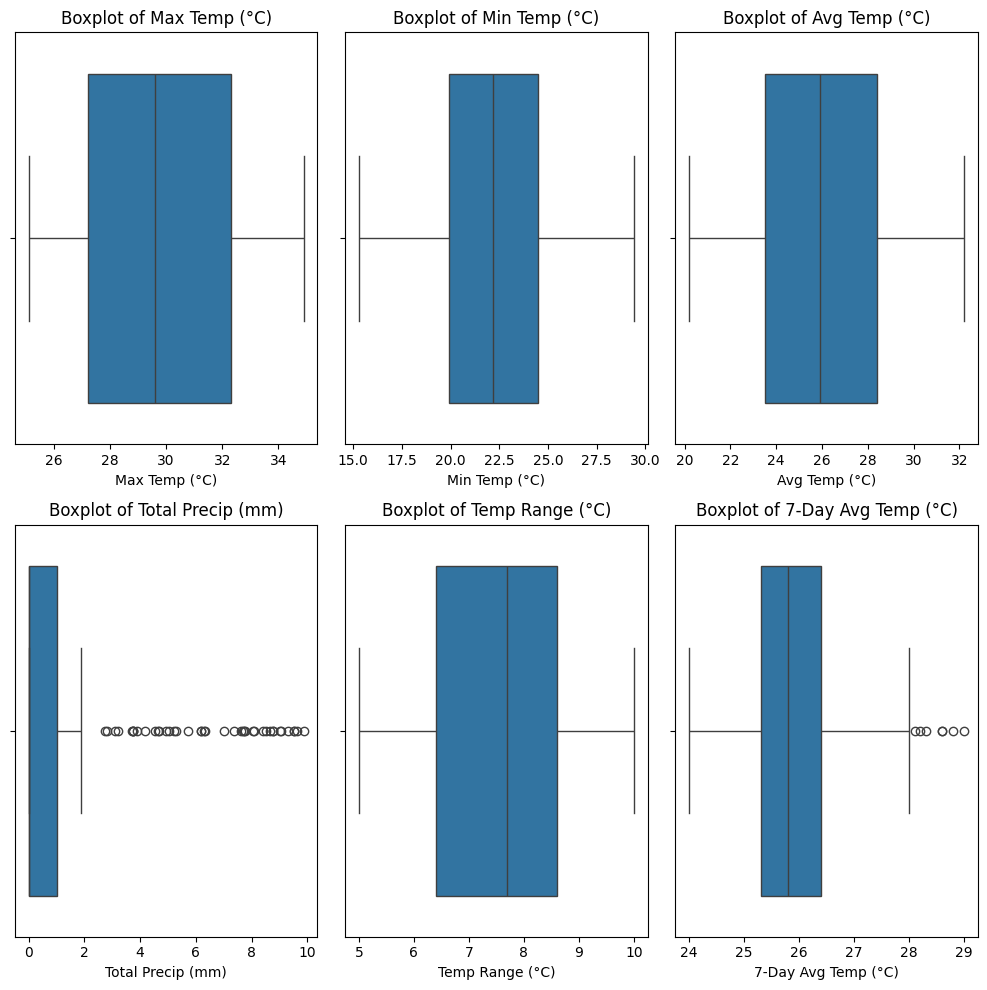

In [11]:
# Select only numeric columns
numeric_columns = df.select_dtypes(include=['number']).columns

# Create a figure with subplots for each numeric column
plt.figure(figsize=(10, 10))

# Plot boxplot for each numeric column
for i, column in enumerate(numeric_columns):
    plt.subplot(2, 3, i+1)  # Adjust 2, 3 based on the number of columns you have
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    
# Adjust layout
plt.tight_layout()
plt.show()

## using statistical method

In [12]:
# Detect outliers for each numeric column
outliers = pd.DataFrame()

for col in df.select_dtypes(include='number').columns:
    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter outliers
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    # Append to outliers DataFrame
    outliers = pd.concat([outliers, col_outliers])
    
    # Print details for each column
    print(f'Outliers in {col}:')
    print(col_outliers)
    print(f'Count of outliers in {col}: {len(col_outliers)}\n')

# Print total unique outliers (if needed)
outliers = outliers.drop_duplicates()
print('Total Unique Outliers:')
print(outliers)
print(f'Total Count of Unique Outliers: {len(outliers)}')


Outliers in Max Temp (°C):
Empty DataFrame
Columns: [Date, Max Temp (°C), Min Temp (°C), Avg Temp (°C), Total Precip (mm), Condition, Temp Range (°C), Season, 7-Day Avg Temp (°C)]
Index: []
Count of outliers in Max Temp (°C): 0

Outliers in Min Temp (°C):
Empty DataFrame
Columns: [Date, Max Temp (°C), Min Temp (°C), Avg Temp (°C), Total Precip (mm), Condition, Temp Range (°C), Season, 7-Day Avg Temp (°C)]
Index: []
Count of outliers in Min Temp (°C): 0

Outliers in Avg Temp (°C):
Empty DataFrame
Columns: [Date, Max Temp (°C), Min Temp (°C), Avg Temp (°C), Total Precip (mm), Condition, Temp Range (°C), Season, 7-Day Avg Temp (°C)]
Index: []
Count of outliers in Avg Temp (°C): 0

Outliers in Total Precip (mm):
          Date  Max Temp (°C)  Min Temp (°C)  Avg Temp (°C)  \
5   2024-07-13           26.6           21.1           23.8   
13  2024-07-21           27.1           17.7           22.4   
14  2024-07-22           26.8           17.9           22.4   
15  2024-07-23           26.8 

## handling the outliers

In [13]:
# Replace outliers with the median and count remaining outliers
outliers_after = 0

for col in df.select_dtypes(include='number').columns:
    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Calculate median
    median = df[col].median()
    
    # Replace outliers with median
    df[col] = df[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
    
    # Count remaining outliers
    outliers_after += len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

print(f'Count of outliers after replacement: {outliers_after}')


Count of outliers after replacement: 0


## checking stationarity

In [14]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test on each column and check stationarity
def check_stationarity(df):
    stationarity_results = {}

    for col in df.select_dtypes(include='number').columns:
        result = adfuller(df[col].dropna())  # Drop NA values before performing ADF test
        stationarity_results[col] = {
            'ADF Statistic': result[0],
            'p-value': result[1],
            'Stationary': result[1] <= 0.05  # p-value <= 0.05 means the series is stationary
        }
    
    return stationarity_results

# Get stationarity results
stationarity_results = check_stationarity(df)

# Print the results
for col, result in stationarity_results.items():
    print(f"Column: {col}")
    print(f"  ADF Statistic: {result['ADF Statistic']}")
    print(f"  p-value: {result['p-value']}")
    print(f"  Stationary: {result['Stationary']}")
    print('-' * 40)


Column: Max Temp (°C)
  ADF Statistic: -13.434796609266867
  p-value: 3.9490826819784767e-25
  Stationary: True
----------------------------------------
Column: Min Temp (°C)
  ADF Statistic: -13.166058438505816
  p-value: 1.2783183056476788e-24
  Stationary: True
----------------------------------------
Column: Avg Temp (°C)
  ADF Statistic: -13.45400449724535
  p-value: 3.6372757163591514e-25
  Stationary: True
----------------------------------------
Column: Total Precip (mm)
  ADF Statistic: -14.84666191475311
  p-value: 1.80298232062125e-27
  Stationary: True
----------------------------------------
Column: Temp Range (°C)
  ADF Statistic: -4.035274863646755
  p-value: 0.0012366579893547229
  Stationary: True
----------------------------------------
Column: 7-Day Avg Temp (°C)
  ADF Statistic: -6.320186455372079
  p-value: 3.0797694285567626e-08
  Stationary: True
----------------------------------------


In [15]:
#all the columns are stationary

## Data splitting

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
# Example: Generating a sample time series data (replace with your actual data)
# Assume 'Date' is the index and 'Value' is the target column
# df = pd.read_csv('your_data.csv') # Uncomment this to load your data
# For the sake of illustration, let's create a simple time series
# Split the data into training and testing sets
train_size = int(len(df) * 0.8)  # 80% training, 20% testing
train, test = df[:train_size], df[train_size:]
print(f"Training set length: {len(train)}")
print(f"Testing set length: {len(test)}")
# Save the training and testing data (optional)
train.to_csv('train_data.csv')
test.to_csv('test_data.csv')

Training set length: 148
Testing set length: 37


# Modeling

## ARIMA Model

In [17]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
train = pd.read_csv('train_data.csv', index_col='Date', parse_dates=True)

# Fit the ARIMA model (adjust the order (p,d,q) as needed)
model = ARIMA(train['Max Temp (°C)'], order=(5, 1, 0))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:          Max Temp (°C)   No. Observations:                  148
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -380.245
Date:                Thu, 09 Jan 2025   AIC                            772.491
Time:                        10:41:44   BIC                            790.433
Sample:                    07-08-2024   HQIC                           779.781
                         - 12-02-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7141      0.084     -8.547      0.000      -0.878      -0.550
ar.L2         -0.5160      0.099     -5.225      0.000      -0.710      -0.322
ar.L3         -0.4250      0.098     -4.330      0.0

C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Forecasting for jan 9th

In [18]:
# Forecast for the next day (January 9th, 2025)
forecast_result = model_fit.get_forecast(steps=1)

# Get forecast value and confidence intervals
forecast_value = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Print forecasted temperature and confidence interval
print("Forecasted Max Temperature for January 9th, 2025:")
print(f"Temperature: {forecast_value.iloc[0]:.2f}°C")
print(f"Confidence Interval: {conf_int.iloc[0].values[0]:.2f}°C to {conf_int.iloc[0].values[1]:.2f}°C")


Forecasted Max Temperature for January 9th, 2025:
Temperature: 29.25°C
Confidence Interval: 22.97°C to 35.53°C


## Plotting the forecast

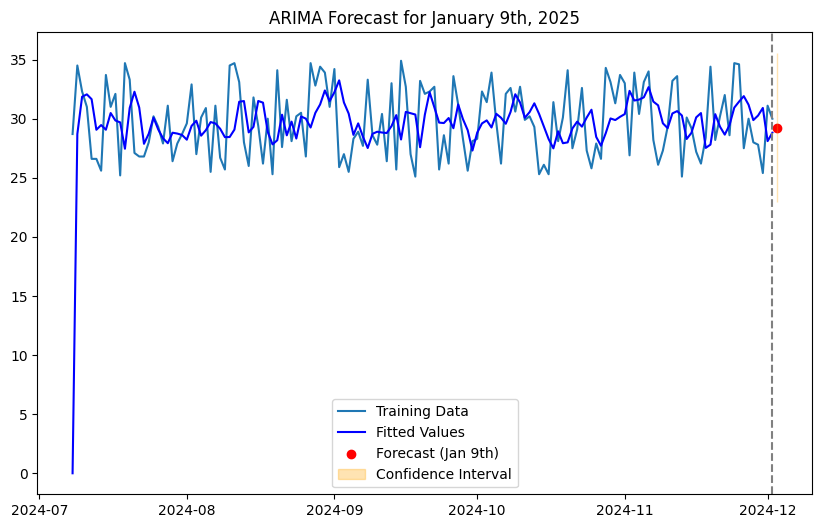

In [19]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Max Temp (°C)'], label='Training Data')
plt.plot(train.index, model_fit.fittedvalues, label='Fitted Values', color='blue')

# Plot forecast for January 9th
plt.axvline(x=train.index[-1], color='gray', linestyle='--')
plt.scatter(train.index[-1] + pd.Timedelta(days=1), forecast_value, color='red', label='Forecast (Jan 9th)')
plt.fill_between([train.index[-1] + pd.Timedelta(days=1)] * 2,
                 conf_int.iloc[0, 0],
                 conf_int.iloc[0, 1],
                 color='orange', alpha=0.3, label='Confidence Interval')

plt.title('ARIMA Forecast for January 9th, 2025')
plt.legend()
plt.show()


In [24]:
# Load the test data
test = pd.read_csv('test_data.csv', index_col='Date', parse_dates=True)

# Forecast the same number of steps as in the test set
forecast = model_fit.forecast(steps=len(test))

# Add the forecast to the test DataFrame
test['Forecast'] = forecast


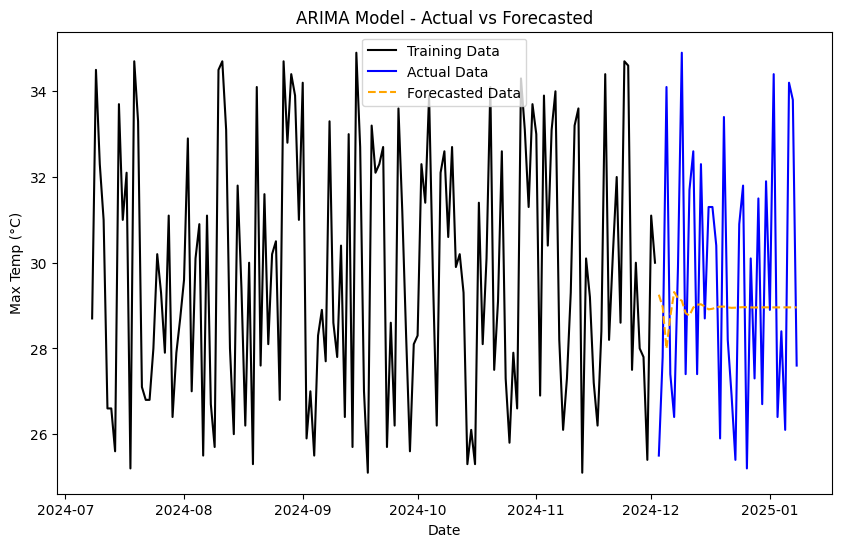

In [26]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(train['Max Temp (°C)'], label='Training Data', color='black')
plt.plot(test['Max Temp (°C)'], label='Actual Data', color='blue')
plt.plot(test['Forecast'], label='Forecasted Data', color='orange', linestyle='--')
plt.title('ARIMA Model - Actual vs Forecasted')
plt.xlabel('Date')
plt.ylabel('Max Temp (°C)')
plt.legend()
plt.show()


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
mae = mean_absolute_error(test['Max Temp (°C)'], test['Forecast'])
rmse = mean_squared_error(test['Max Temp (°C)'], test['Forecast'], squared=False)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


Mean Absolute Error (MAE): 2.622306874909905
Root Mean Squared Error (RMSE): 3.0392400837536884


C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Holt-Winters Exponential Smoothing

In [28]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import matplotlib.pyplot as plt
# Load the training data
train = pd.read_csv('train_data.csv', index_col='Date', parse_dates=True)

# Fit the Holt-Winters model (additive or multiplicative seasonality can be specified)
model = ExponentialSmoothing(train['Max Temp (°C)'], trend='add', seasonal='add', seasonal_periods=12)
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())



                       ExponentialSmoothing Model Results                       
Dep. Variable:            Max Temp (°C)   No. Observations:                  148
Model:             ExponentialSmoothing   SSE                           1203.099
Optimized:                         True   AIC                            342.126
Trend:                         Additive   BIC                            390.081
Seasonal:                      Additive   AICC                           347.428
Seasonal Periods:                    12   Date:                 Thu, 09 Jan 2025
Box-Cox:                          False   Time:                         11:03:15
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level              1.4901e-08                alpha                 True
smoothing_trend          

C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [29]:
# Load the test data
test = pd.read_csv('test_data.csv', index_col='Date', parse_dates=True)

# Forecast the same number of steps as in the test set
forecast = model_fit.forecast(steps=len(test))

# Add the forecast to the test DataFrame
test['Forecast'] = forecast


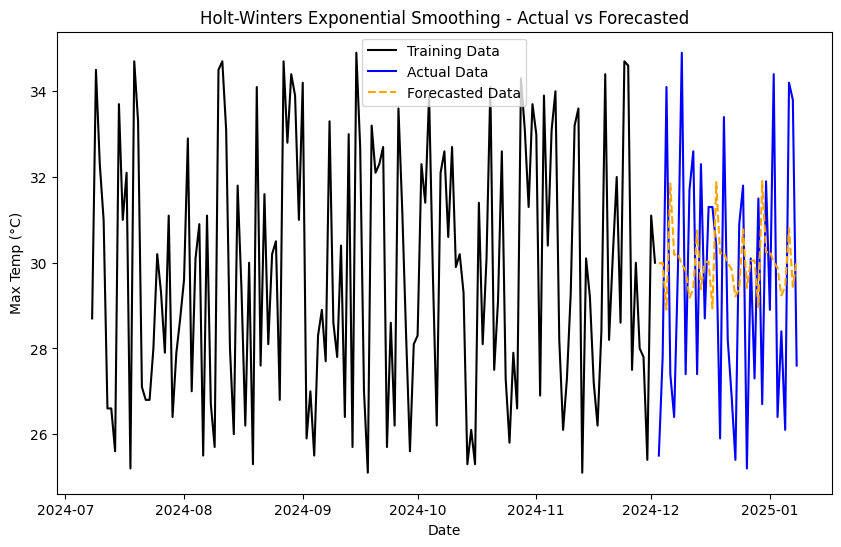

In [32]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(train['Max Temp (°C)'], label='Training Data', color='black')
plt.plot(test['Max Temp (°C)'], label='Actual Data', color='blue')
plt.plot(test['Forecast'], label='Forecasted Data', color='orange', linestyle='--')
plt.title('Holt-Winters Exponential Smoothing - Actual vs Forecasted')
plt.xlabel('Date')
plt.ylabel('Max Temp (°C)')
plt.legend()
plt.show()


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
mae = mean_absolute_error(test['Max Temp (°C)'], test['Forecast'])
rmse = mean_squared_error(test['Max Temp (°C)'], test['Forecast'], squared=False)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


Mean Absolute Error (MAE): 2.8325889606966714
Root Mean Squared Error (RMSE): 3.1431292907921535


C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
